In [7]:
import numpy as np
import matplotlib.pyplot as plt
import control as ctl

In [ ]:
def PID(error, errPrev, errAcum, dt):
    Kp = 0
    Ki = 0
    Kd = 0
    return Kp * error + Ki * errAcum * dt + Kd * (error - errPrev) / dt

# Ignoring rotor dynamics
def plantModel():
    return

In [10]:
N = 1955

setpoint = np.ones(N)
setpoint[0] = 0

outputs = np.zeros(N)

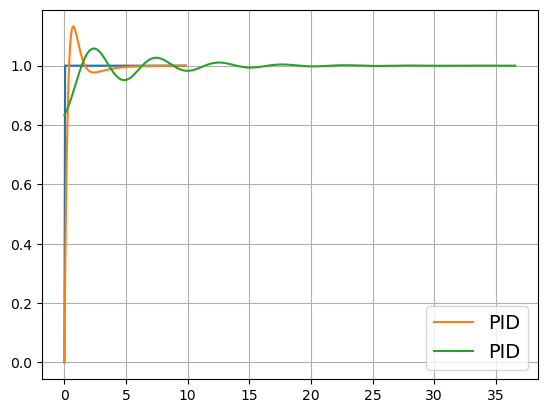

In [31]:
J = 0.2
b = 0.1
k = 0.1
Ku = 1.0

# Plant
G = ctl.tf([Ku], [J, b, k])

# PID
Kp = 2
Ki = 1
Kd = 1

#PIDA
Ka = 1

C = ctl.tf([Kd, Kp, Ki], [1, 0])
C_a = ctl.tf([Ka, Kd, Kp, Ki], [1, 0])

# Closed loop
T = ctl.feedback(C*G, 1)
T_a = ctl.feedback(C_a*G, 1)

# Step response
t, y = ctl.step_response(T)
t_a, y_a = ctl.step_response(T_a)

setpoint = np.ones(len(y))
setpoint[0] = 0

plt.plot(t, setpoint)
plt.plot(t, y, label = "PID")
plt.plot(t_a, y_a, label = "PID")

plt.legend(fontsize = 14)
plt.grid()
plt.show()